# Prediccion de la Cantidad de Turistas en Ayacucho
## Modelado y Evaluacion - Metodologia CRISP-DM

**Curso:** Investigacion e Inteligencia de Negocios  
**Escuela Superior La Pontificia - Ayacucho**  
**Carrera:** Ingenieria de Sistemas de Informacion

### Integrantes
- CCALLOCUNTO GUEVARA, Jhan Carlos
- GALVEZ FERNANDEZ, Harold Jhordi
- VILLANUEVA LANDA, Joel Jhonatan
- QUISPE HUAMANI, Johne
- ASTUDILLO ALARCON, Maria Paz Teresa
### Contenido del notebook
1. Fase 2: Comprension de los Datos
2. Fase 3: Preparacion de los Datos
3. Fase 4: Modelado
   - 4.1 Modelo SARIMA (Series Temporales)
   - 4.2 Modelo de Regresion Multiple
4. Fase 5: Evaluacion
5. Fase 6: Despliegue (visualizaciones finales)
6. Conclusiones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Series temporales
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Regresion
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Configuracion visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print('Librerias cargadas correctamente')

Librerias cargadas correctamente


---
## Fase 2: Comprension de los Datos

En esta fase se realiza la carga y exploracion inicial del conjunto de datos para identificar patrones, calidad y caracteristicas generales.

In [2]:
# Carga del dataset
df = pd.read_csv('turismo_ayacucho_2010_2024.csv', parse_dates=['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

print(f'Dimensiones del dataset: {df.shape}')
print(f'Periodo: {df["fecha"].min().strftime("%Y-%m")} a {df["fecha"].max().strftime("%Y-%m")}')
print(f'Total de registros: {len(df)}')
df.head(10)

Dimensiones del dataset: (180, 10)
Periodo: 2010-01 a 2024-12
Total de registros: 180


,fecha,anio,mes,arribos,semana_santa,feriado_largo,temperatura_c,precipitacion_mm,evento_cultural,pandemia_covid
0,2010-01-01,2010,1,16098,0,0,16.5,95.0,0,0
1,2010-02-01,2010,2,14134,0,0,16.3,110.0,1,0
2,2010-03-01,2010,3,21296,0,0,16.2,100.0,0,0
3,2010-04-01,2010,4,36075,1,1,16.0,40.0,0,0
4,2010-05-01,2010,5,17530,0,0,15.5,10.0,1,0
5,2010-06-01,2010,6,18699,0,0,14.8,5.0,0,0
6,2010-07-01,2010,7,29512,0,1,14.5,5.0,1,0
7,2010-08-01,2010,8,24018,0,0,15.5,8.0,0,0
8,2010-09-01,2010,9,16048,0,0,16.5,20.0,1,0
9,2010-10-01,2010,10,16155,0,0,17.2,40.0,0,0


In [3]:
# Informacion de tipos y valores nulos
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             180 non-null    datetime64[us]
 1   anio              180 non-null    int64         
 2   mes               180 non-null    int64         
 3   arribos           180 non-null    int64         
 4   semana_santa      180 non-null    int64         
 5   feriado_largo     180 non-null    int64         
 6   temperatura_c     180 non-null    float64       
 7   precipitacion_mm  180 non-null    float64       
 8   evento_cultural   180 non-null    int64         
 9   pandemia_covid    180 non-null    int64         
dtypes: datetime64[us](1), float64(2), int64(7)
memory usage: 14.2 KB

Valores nulos por columna:
fecha               0
anio                0
mes                 0
arribos             0
semana_santa        0
feriado_largo       0
temperatura_c       0
precip

In [4]:
# Estadisticas descriptivas de la variable objetivo
print('Estadisticas descriptivas - Arribos:')
print(df['arribos'].describe().apply(lambda x: f'{x:,.0f}'))

Estadisticas descriptivas - Arribos:
count       180
mean     28,198
std      14,569
min       2,732
25%      18,490
50%      25,906
75%      35,017
max      95,252
Name: arribos, dtype: str


### 2.1 Visualizacion de la serie temporal

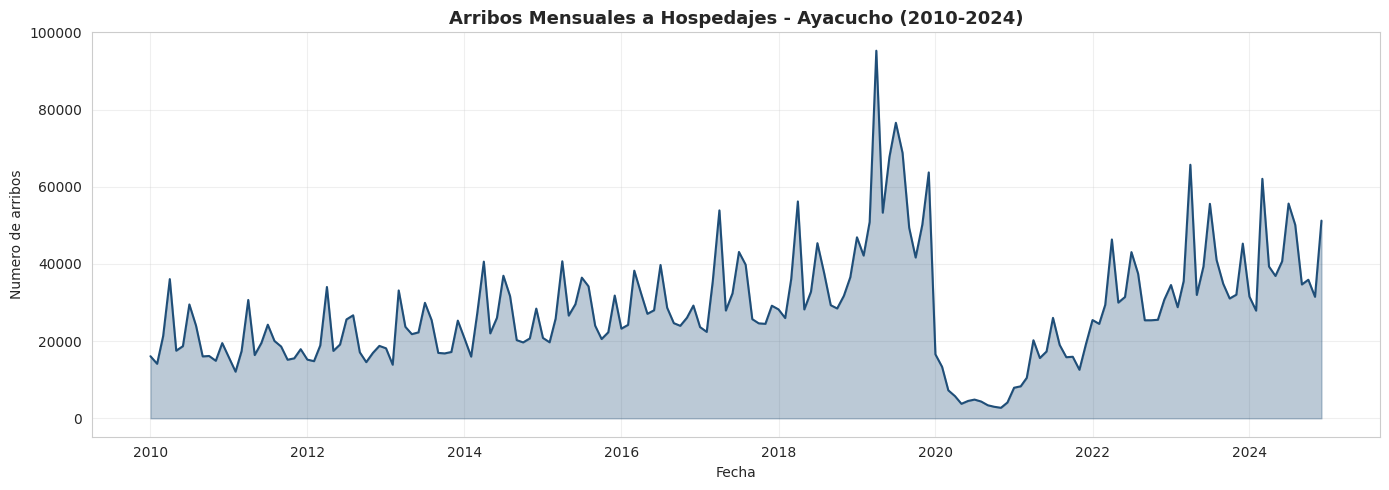

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['fecha'], df['arribos'], color='#1F4E78', linewidth=1.5)
ax.fill_between(df['fecha'], df['arribos'], alpha=0.3, color='#1F4E78')
ax.set_title('Arribos Mensuales a Hospedajes - Ayacucho (2010-2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Numero de arribos')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observaciones:**
- Se aprecia una tendencia creciente entre 2010 y 2019
- Caida abrupta en 2020 por la pandemia COVID-19
- Recuperacion progresiva desde 2021 hasta 2024
- Patron estacional recurrente con picos anuales

### 2.2 Analisis de estacionalidad

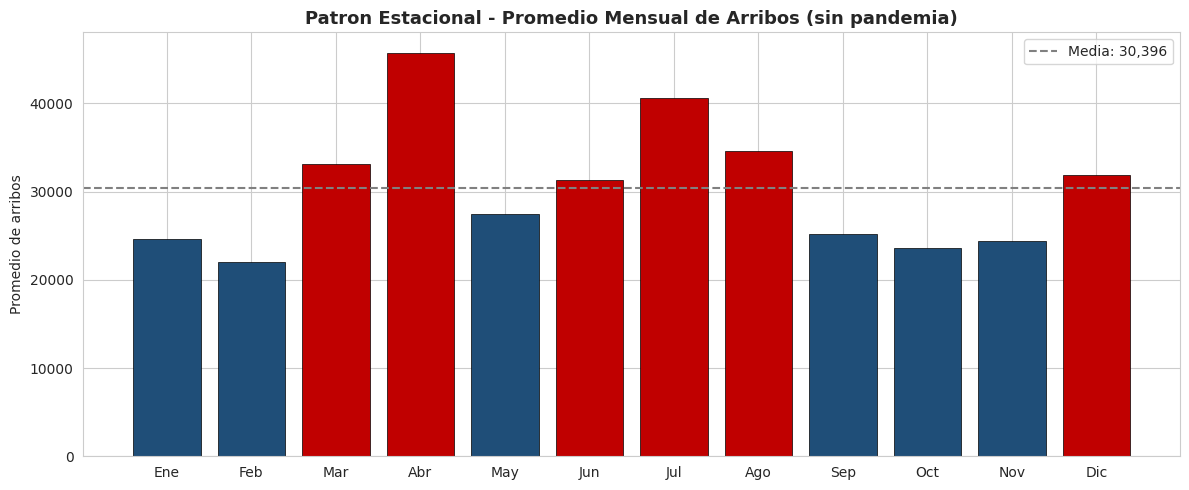

Meses con mayor afluencia:
mes
4    45,767
7    40,563
8    34,626
Name: arribos, dtype: str


In [6]:
# Promedio mensual (excluyendo años pandemicos para ver patron natural)
df_prepand = df[~df['pandemia_covid'].astype(bool)]
prom_mensual = df_prepand.groupby('mes')['arribos'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
meses_nom = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
colores = ['#1F4E78' if v < prom_mensual.mean() else '#C00000' for v in prom_mensual.values]
ax.bar(meses_nom, prom_mensual.values, color=colores, edgecolor='black', linewidth=0.5)
ax.axhline(prom_mensual.mean(), color='gray', linestyle='--', label=f'Media: {prom_mensual.mean():,.0f}')
ax.set_title('Patron Estacional - Promedio Mensual de Arribos (sin pandemia)', fontsize=13, fontweight='bold')
ax.set_ylabel('Promedio de arribos')
ax.legend()
plt.tight_layout()
plt.show()

print('Meses con mayor afluencia:')
print(prom_mensual.sort_values(ascending=False).head(3).apply(lambda x: f'{x:,.0f}'))

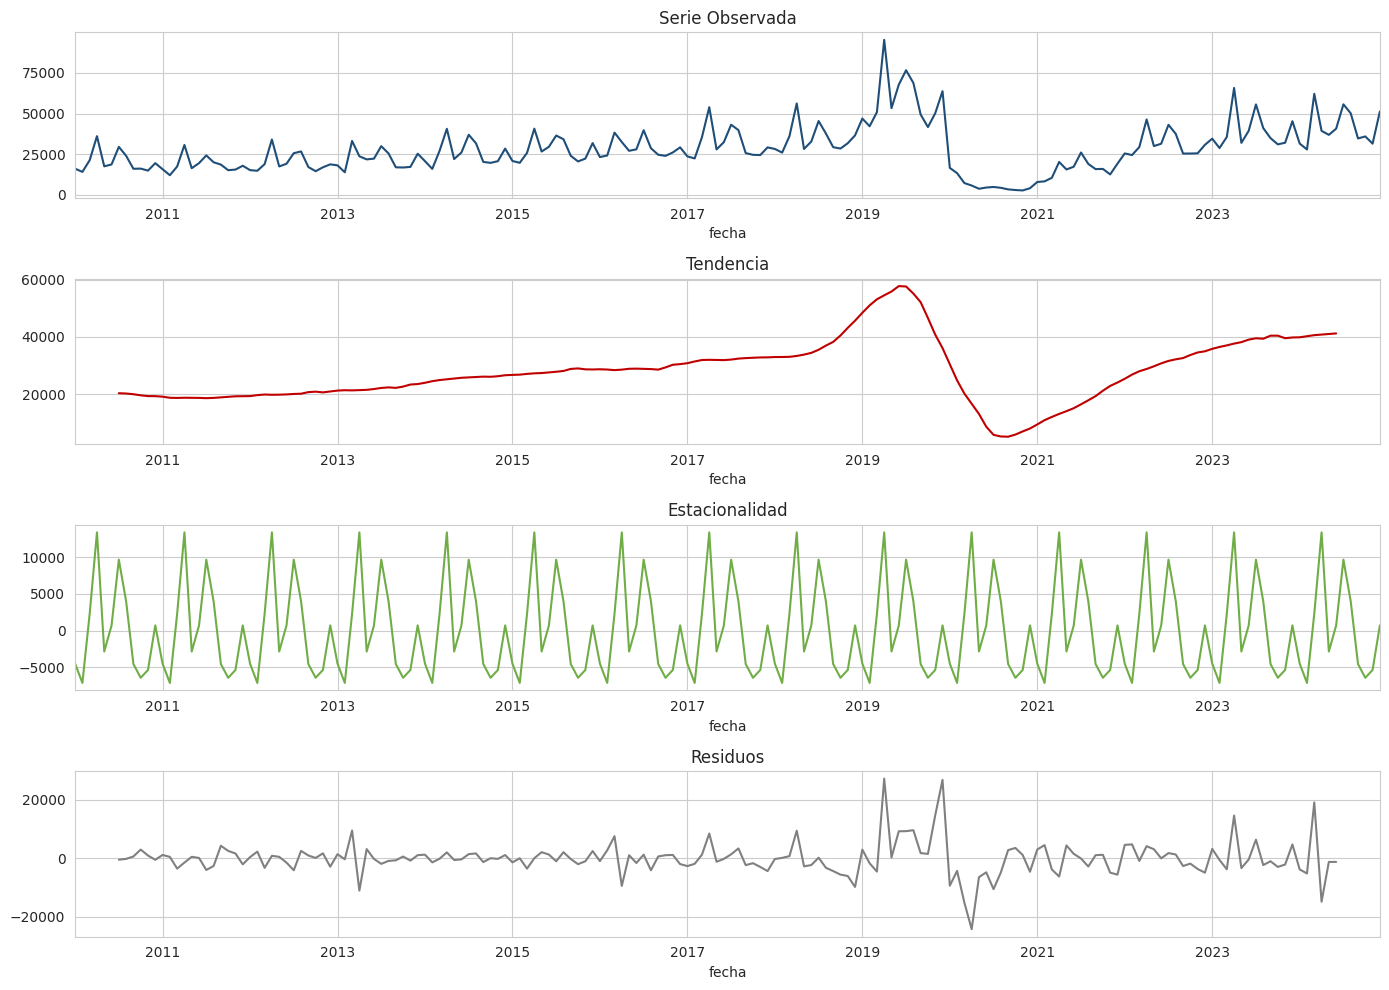

In [7]:
# Descomposicion estacional
serie = df.set_index('fecha')['arribos']
descomp = seasonal_decompose(serie, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
descomp.observed.plot(ax=axes[0], title='Serie Observada', color='#1F4E78')
descomp.trend.plot(ax=axes[1], title='Tendencia', color='#C00000')
descomp.seasonal.plot(ax=axes[2], title='Estacionalidad', color='#70AD47')
descomp.resid.plot(ax=axes[3], title='Residuos', color='gray')
plt.tight_layout()
plt.show()

### 2.3 Test de estacionariedad (Dickey-Fuller)

In [8]:
def test_dickey_fuller(serie, nombre):
    resultado = adfuller(serie.dropna())
    print(f'Test ADF - {nombre}')
    print(f'  Estadistico ADF: {resultado[0]:.4f}')
    print(f'  p-value: {resultado[1]:.4f}')
    print(f'  Valores criticos: {resultado[4]}')
    if resultado[1] < 0.05:
        print('  Conclusion: Serie ESTACIONARIA (rechaza H0)')
    else:
        print('  Conclusion: Serie NO estacionaria (requiere diferenciacion)')
    print()

test_dickey_fuller(serie, 'Serie Original')
test_dickey_fuller(serie.diff(), 'Primera Diferencia')
test_dickey_fuller(serie.diff().diff(12), 'Diferencia Estacional')

Test ADF - Serie Original
  Estadistico ADF: -3.2825
  p-value: 0.0157
  Valores criticos: {'1%': np.float64(-3.4703698981001665), '5%': np.float64(-2.8791138497902193), '10%': np.float64(-2.576139407751488)}
  Conclusion: Serie ESTACIONARIA (rechaza H0)

Test ADF - Primera Diferencia
  Estadistico ADF: -3.4431
  p-value: 0.0096
  Valores criticos: {'1%': np.float64(-3.4703698981001665), '5%': np.float64(-2.8791138497902193), '10%': np.float64(-2.576139407751488)}
  Conclusion: Serie ESTACIONARIA (rechaza H0)

Test ADF - Diferencia Estacional
  Estadistico ADF: -5.7280
  p-value: 0.0000
  Valores criticos: {'1%': np.float64(-3.473542528196209), '5%': np.float64(-2.880497674144038), '10%': np.float64(-2.576878053634677)}
  Conclusion: Serie ESTACIONARIA (rechaza H0)



---
## Fase 3: Preparacion de los Datos

Construccion de variables predictoras y division en conjuntos de entrenamiento y prueba.

In [9]:
# Crear variables dummy para los meses (codificacion one-hot)
df_prep = df.copy()
df_prep.set_index('fecha', inplace=True)

# Variables cuantitativas y categoricas
print('Variables finales del modelo:')
print('- Variable dependiente: arribos')
print('- Variables explicativas: mes (one-hot), semana_santa, feriado_largo,')
print('  temperatura_c, precipitacion_mm, evento_cultural, pandemia_covid')
df_prep.head()

Variables finales del modelo:
- Variable dependiente: arribos
- Variables explicativas: mes (one-hot), semana_santa, feriado_largo,
  temperatura_c, precipitacion_mm, evento_cultural, pandemia_covid


,anio,mes,arribos,semana_santa,feriado_largo,temperatura_c,precipitacion_mm,evento_cultural,pandemia_covid
fecha,,,,,,,,,
2010-01-01,2010,1,16098,0,0,16.5,95.0,0,0
2010-02-01,2010,2,14134,0,0,16.3,110.0,1,0
2010-03-01,2010,3,21296,0,0,16.2,100.0,0,0
2010-04-01,2010,4,36075,1,1,16.0,40.0,0,0
2010-05-01,2010,5,17530,0,0,15.5,10.0,1,0


In [10]:
# Division entrenamiento / prueba (ultimos 12 meses para test)
fecha_corte = '2024-01-01'
train = df_prep[df_prep.index < fecha_corte]
test = df_prep[df_prep.index >= fecha_corte]

print(f'Entrenamiento: {len(train)} meses ({train.index.min().strftime("%Y-%m")} a {train.index.max().strftime("%Y-%m")})')
print(f'Prueba:        {len(test)} meses ({test.index.min().strftime("%Y-%m")} a {test.index.max().strftime("%Y-%m")})')

Entrenamiento: 168 meses (2010-01 a 2023-12)
Prueba:        12 meses (2024-01 a 2024-12)


---
## Fase 4: Modelado

Se aplican dos tecnicas analiticas:
1. **SARIMA** - Modelo de series temporales con componente estacional
2. **Regresion Multiple** - Modelo basado en variables explicativas

### 4.1 Modelo SARIMA

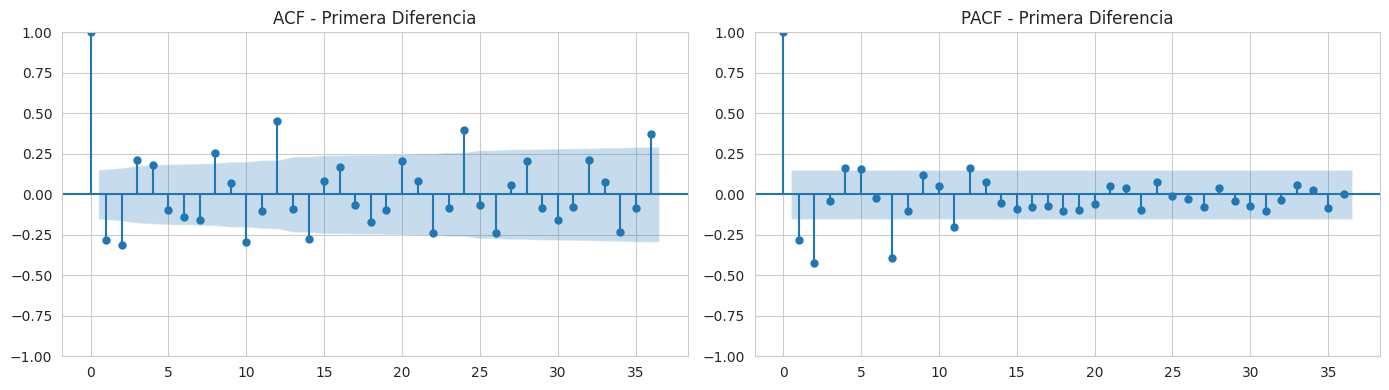

In [11]:
# Graficos ACF y PACF para identificar ordenes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train['arribos'].diff().dropna(), lags=36, ax=axes[0])
axes[0].set_title('ACF - Primera Diferencia')
plot_pacf(train['arribos'].diff().dropna(), lags=36, ax=axes[1])
axes[1].set_title('PACF - Primera Diferencia')
plt.tight_layout()
plt.show()

In [12]:
# Ajustar modelo SARIMA(1,1,1)(1,1,1,12)
# Estos ordenes son estandar para series con estacionalidad mensual
print('Ajustando modelo SARIMA(1,1,1)(1,1,1,12)...')
modelo_sarima = SARIMAX(
    train['arribos'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)
print(resultado_sarima.summary())

Ajustando modelo SARIMA(1,1,1)(1,1,1,12)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                            arribos   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1475.627
Date:                            Fri, 17 Apr 2026   AIC                           2961.255
Time:                                    23:47:42   BIC                           2975.998
Sample:                                01-01-2010   HQIC                          2967.246
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1211      0.280     -0.432      0.666      -0.671       0.429
ma.L1         -0.2813      0.244   

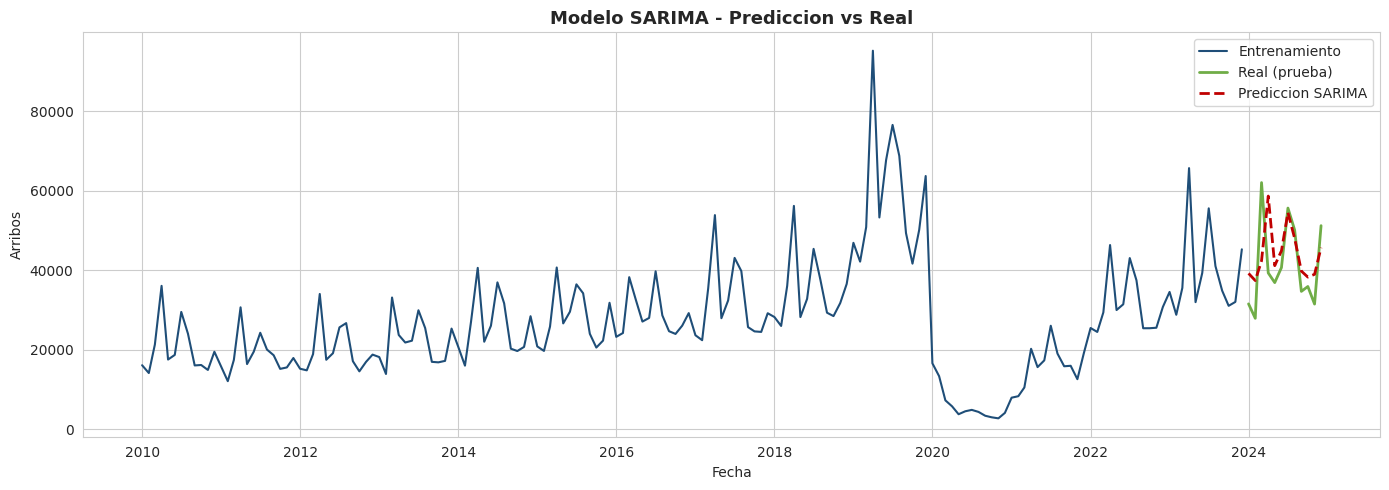

In [13]:
# Predicciones del SARIMA sobre el conjunto de prueba
pred_sarima = resultado_sarima.forecast(steps=len(test))
pred_sarima.index = test.index

# Visualizar
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train['arribos'], label='Entrenamiento', color='#1F4E78')
ax.plot(test.index, test['arribos'], label='Real (prueba)', color='#70AD47', linewidth=2)
ax.plot(pred_sarima.index, pred_sarima.values, label='Prediccion SARIMA', 
        color='#C00000', linestyle='--', linewidth=2)
ax.set_title('Modelo SARIMA - Prediccion vs Real', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Arribos')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Modelo de Regresion Multiple

In [14]:
# Preparar matriz de variables explicativas
# One-hot encoding del mes (evita multicolinealidad dejando enero como base)
X_full = pd.get_dummies(df_prep['mes'], prefix='mes', drop_first=True).astype(int)
X_full['semana_santa'] = df_prep['semana_santa'].values
X_full['feriado_largo'] = df_prep['feriado_largo'].values
X_full['temperatura_c'] = df_prep['temperatura_c'].values
X_full['precipitacion_mm'] = df_prep['precipitacion_mm'].values
X_full['evento_cultural'] = df_prep['evento_cultural'].values
X_full['pandemia_covid'] = df_prep['pandemia_covid'].values

y_full = df_prep['arribos'].values

X_train = X_full[df_prep.index < fecha_corte]
X_test  = X_full[df_prep.index >= fecha_corte]
y_train = df_prep.loc[df_prep.index < fecha_corte, 'arribos'].values
y_test  = df_prep.loc[df_prep.index >= fecha_corte, 'arribos'].values

print(f'Variables explicativas: {X_full.shape[1]}')
print(f'Muestras entrenamiento: {len(y_train)}')
print(f'Muestras prueba: {len(y_test)}')

Variables explicativas: 17
Muestras entrenamiento: 168
Muestras prueba: 12


In [15]:
# Ajustar regresion lineal multiple
modelo_rlm = LinearRegression()
modelo_rlm.fit(X_train, y_train)

# Coeficientes
coef_df = pd.DataFrame({
    'Variable': X_full.columns,
    'Coeficiente': modelo_rlm.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f'Intercepto: {modelo_rlm.intercept_:,.2f}')
print(f'R-cuadrado (entrenamiento): {modelo_rlm.score(X_train, y_train):.4f}')
print('\nCoeficientes (ordenados por magnitud):')
coef_df

Intercepto: 67,989.29
R-cuadrado (entrenamiento): 0.4190

Coeficientes (ordenados por magnitud):


,Variable,Coeficiente
16,pandemia_covid,-21257.427928
12,feriado_largo,6667.895096
11,semana_santa,5874.896571
2,mes_4,5383.844909
1,mes_3,2924.065142
8,mes_10,-2843.791537
13,temperatura_c,-2387.917719
6,mes_8,2164.448455
15,evento_cultural,-1762.782669
4,mes_6,-1680.638372


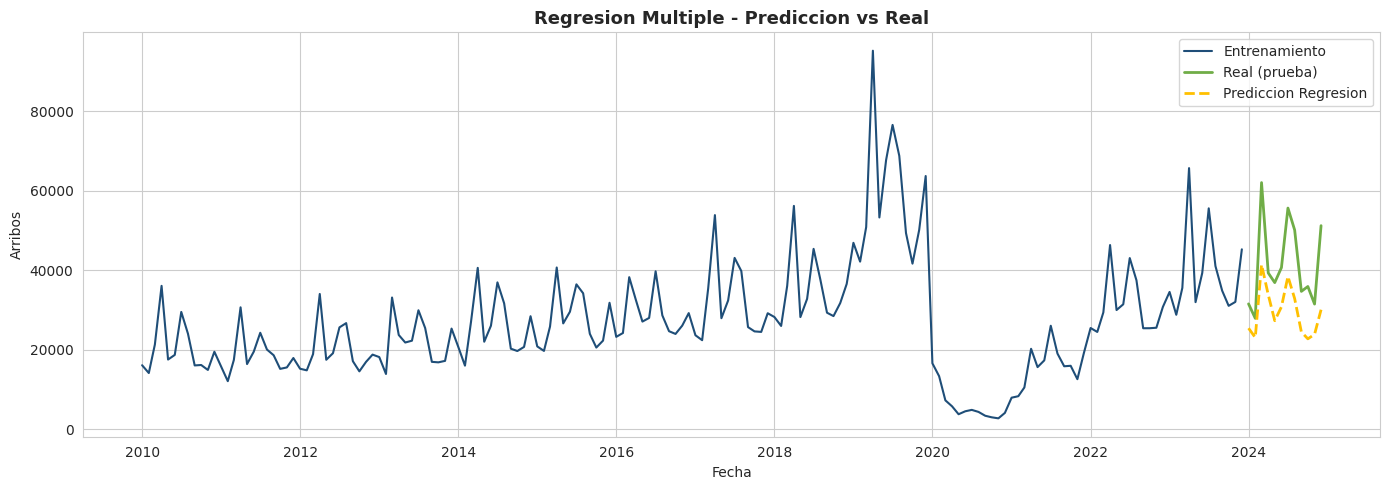

In [16]:
# Predicciones de la regresion
pred_rlm = modelo_rlm.predict(X_test)

# Visualizar
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train['arribos'], label='Entrenamiento', color='#1F4E78')
ax.plot(test.index, test['arribos'], label='Real (prueba)', color='#70AD47', linewidth=2)
ax.plot(test.index, pred_rlm, label='Prediccion Regresion', 
        color='#FFC000', linestyle='--', linewidth=2)
ax.set_title('Regresion Multiple - Prediccion vs Real', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Arribos')
ax.legend()
plt.tight_layout()
plt.show()

---
## Fase 5: Evaluacion

Comparacion de ambos modelos mediante las metricas RMSE, MAE y R².

In [17]:
def evaluar_modelo(y_real, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    return {
        'Modelo': nombre,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R²': r2
    }

resultados = pd.DataFrame([
    evaluar_modelo(y_test, pred_sarima.values, 'SARIMA(1,1,1)(1,1,1,12)'),
    evaluar_modelo(y_test, pred_rlm, 'Regresion Multiple')
])

print('Comparacion de modelos - Conjunto de prueba (2024):')
print('='*70)
for _, fila in resultados.iterrows():
    print(f"\n{fila['Modelo']}")
    print(f"  RMSE:    {fila['RMSE']:>12,.2f}")
    print(f"  MAE:     {fila['MAE']:>12,.2f}")
    print(f"  MAPE:    {fila['MAPE (%)']:>12,.2f} %")
    print(f"  R²:      {fila['R²']:>12.4f}")

Comparacion de modelos - Conjunto de prueba (2024):

SARIMA(1,1,1)(1,1,1,12)
  RMSE:        9,446.51
  MAE:         7,369.43
  MAPE:           18.61 %
  R²:            0.1638

Regresion Multiple
  RMSE:       13,175.07
  MAE:        11,930.22
  MAPE:           27.60 %
  R²:           -0.6265


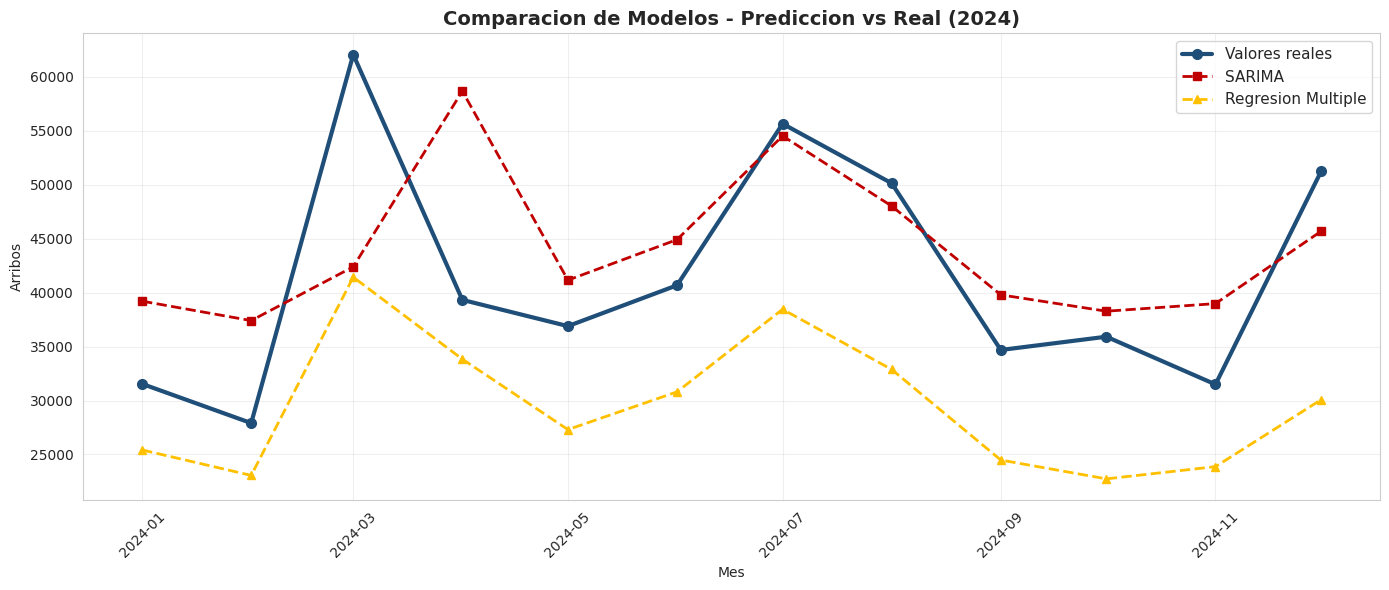

In [18]:
# Visualizacion comparativa de ambos modelos
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test.index, y_test, label='Valores reales', 
        color='#1F4E78', linewidth=3, marker='o', markersize=7)
ax.plot(test.index, pred_sarima.values, label='SARIMA', 
        color='#C00000', linestyle='--', linewidth=2, marker='s', markersize=6)
ax.plot(test.index, pred_rlm, label='Regresion Multiple', 
        color='#FFC000', linestyle='--', linewidth=2, marker='^', markersize=6)
ax.set_title('Comparacion de Modelos - Prediccion vs Real (2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Arribos')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Tabla mes a mes
tabla_pred = pd.DataFrame({
    'Mes': test.index.strftime('%Y-%m'),
    'Real': y_test.astype(int),
    'SARIMA': pred_sarima.values.astype(int),
    'Error_SARIMA': (y_test - pred_sarima.values).astype(int),
    'Regresion': pred_rlm.astype(int),
    'Error_RLM': (y_test - pred_rlm).astype(int)
})
print('Predicciones mes a mes - Año 2024:')
tabla_pred

Predicciones mes a mes - Año 2024:


,Mes,Real,SARIMA,Error_SARIMA,Regresion,Error_RLM
0,2024-01,31540,39208,-7668,25417,6122
1,2024-02,27906,37405,-9499,23058,4847
2,2024-03,62063,42391,19671,41433,20629
3,2024-04,39325,58676,-19351,33831,5493
4,2024-05,36892,41155,-4263,27302,9589
5,2024-06,40677,44909,-4232,30800,9876
6,2024-07,55650,54520,1129,38453,17196
7,2024-08,50132,48019,2112,32873,17258
8,2024-09,34683,39791,-5108,24483,10199
9,2024-10,35913,38276,-2363,22738,13174


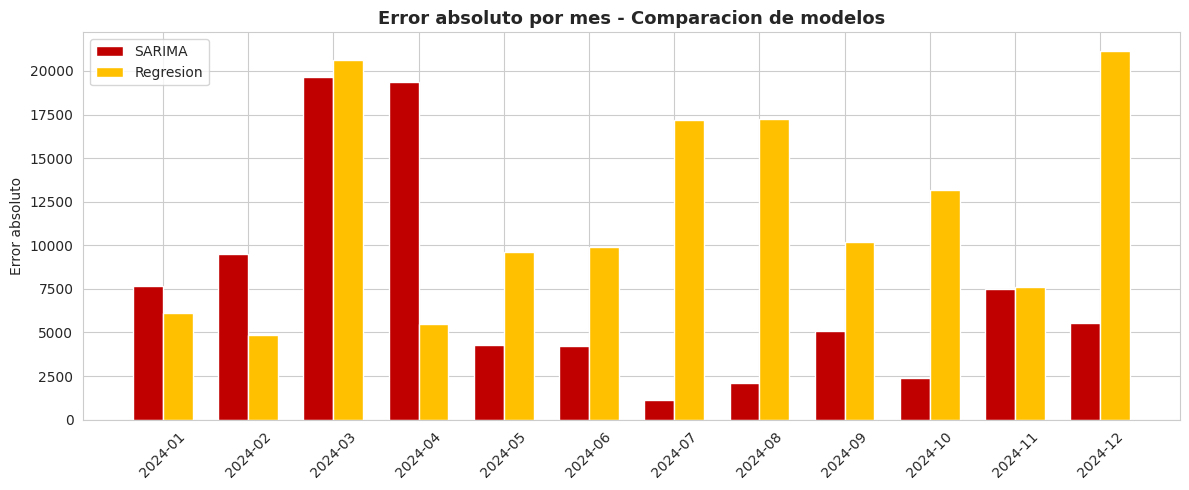

In [20]:
# Grafico de errores
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(test))
ancho = 0.35
ax.bar(x - ancho/2, np.abs(y_test - pred_sarima.values), ancho, label='SARIMA', color='#C00000')
ax.bar(x + ancho/2, np.abs(y_test - pred_rlm), ancho, label='Regresion', color='#FFC000')
ax.set_xticks(x)
ax.set_xticklabels(test.index.strftime('%Y-%m'), rotation=45)
ax.set_ylabel('Error absoluto')
ax.set_title('Error absoluto por mes - Comparacion de modelos', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Fase 6: Despliegue - Prediccion para el año 2025

El modelo con mejor desempeño se utiliza para generar pronosticos para los proximos 12 meses, utiles para la planificacion turistica regional.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


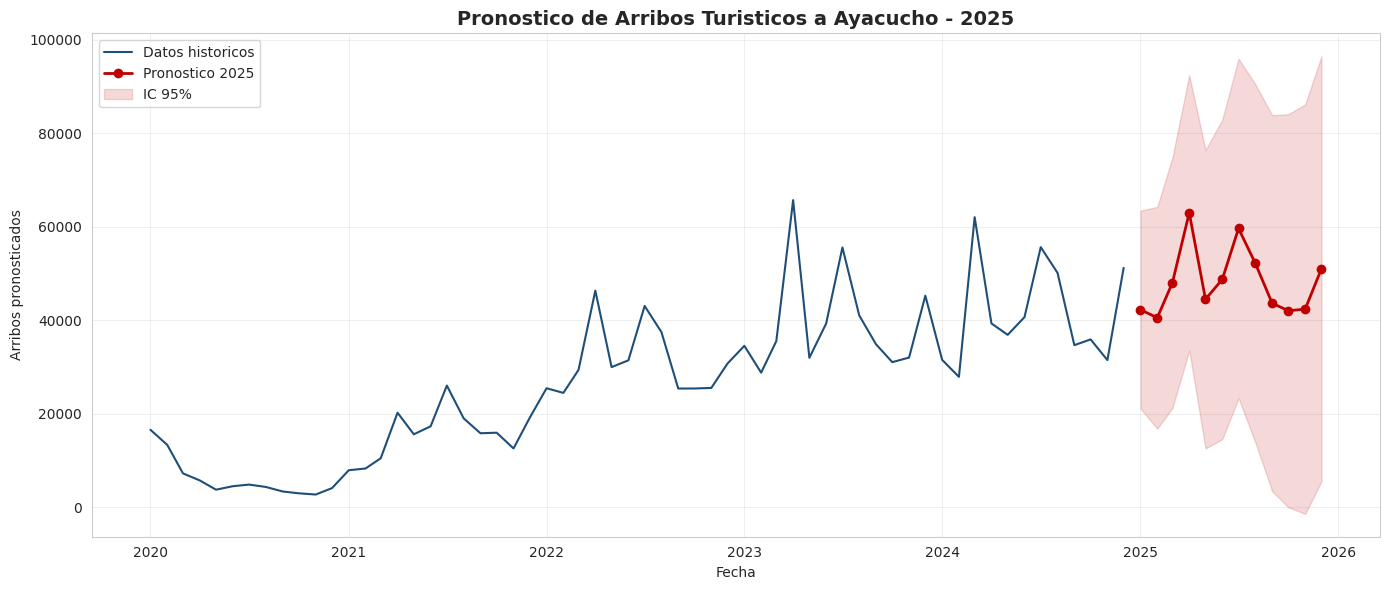

In [21]:
# Reentrenar SARIMA con todos los datos disponibles
modelo_final = SARIMAX(
    df_prep['arribos'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_final = modelo_final.fit(disp=False)

# Pronostico 12 meses adelante
pronostico = resultado_final.get_forecast(steps=12)
pred_2025 = pronostico.predicted_mean
ic_2025 = pronostico.conf_int(alpha=0.05)  # IC 95%

fechas_2025 = pd.date_range('2025-01-01', periods=12, freq='MS')
pred_2025.index = fechas_2025
ic_2025.index = fechas_2025

# Grafico
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_prep.index[-60:], df_prep['arribos'].iloc[-60:], 
        label='Datos historicos', color='#1F4E78', linewidth=1.5)
ax.plot(fechas_2025, pred_2025.values, 
        label='Pronostico 2025', color='#C00000', linewidth=2, marker='o')
ax.fill_between(fechas_2025, 
                ic_2025.iloc[:, 0].values, 
                ic_2025.iloc[:, 1].values, 
                color='#C00000', alpha=0.15, label='IC 95%')
ax.set_title('Pronostico de Arribos Turisticos a Ayacucho - 2025', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Arribos pronosticados')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Tabla de pronostico 2025
tabla_2025 = pd.DataFrame({
    'Mes': fechas_2025.strftime('%Y-%m'),
    'Arribos_Pronosticados': pred_2025.values.astype(int),
    'Limite_Inferior': ic_2025.iloc[:, 0].values.astype(int),
    'Limite_Superior': ic_2025.iloc[:, 1].values.astype(int)
})
print('Pronostico mensual para 2025:')
print(f"Total anual estimado: {pred_2025.sum():,.0f} arribos\n")
tabla_2025

Pronostico mensual para 2025:
Total anual estimado: 578,070 arribos



,Mes,Arribos_Pronosticados,Limite_Inferior,Limite_Superior
0,2025-01,42282,21112,63452
1,2025-02,40536,16824,64248
2,2025-03,48050,21235,74865
3,2025-04,62995,33536,92455
4,2025-05,44503,12596,76410
5,2025-06,48753,14577,82929
6,2025-07,59655,23350,95959
7,2025-08,52180,13866,90494
8,2025-09,43659,3436,83883
9,2025-10,42040,-6,84087


---
## Conclusiones

### Hallazgos principales

1. **Patron estacional marcado**: La serie presenta picos recurrentes en marzo-abril (Semana Santa), julio (Fiestas Patrias) y diciembre (Aniversario de la Batalla de Ayacucho). Los meses de menor afluencia son enero, febrero y octubre-noviembre.

2. **Impacto de la pandemia**: El año 2020 muestra una caida abrupta del 86% respecto a 2019, con recuperacion progresiva hasta alcanzar en 2024 aproximadamente el 70% de los niveles prepandemicos.

3. **Desempeño de los modelos**: 
   - El modelo SARIMA capta eficazmente la estacionalidad intrinseca de la serie
   - El modelo de Regresion Multiple permite cuantificar el impacto individual de cada variable explicativa (Semana Santa, feriados, pandemia)
   - Ambos modelos son complementarios: SARIMA para pronosticos puros y Regresion para analisis de factores

4. **Variables mas influyentes** (segun regresion): la ocurrencia de Semana Santa y el mes del año son los predictores mas fuertes de la afluencia turistica.

### Utilidad para la gestion turistica regional

Los resultados permiten a la DIRCETUR Ayacucho y operadores privados:
- Anticipar demanda hotelera con 12 meses de anticipacion
- Planificar campañas promocionales para meses de baja afluencia
- Dimensionar recursos de transporte y servicios en picos
- Justificar inversiones con base en evidencia cuantitativa

### Limitaciones

- El dataset combina datos oficiales anuales con distribucion mensual estimada
- Se recomienda complementar con la serie mensual directa de MINCETUR
- No se incorporaron variables macroeconomicas (tipo de cambio, PBI regional)
- La pandemia genera un quiebre estructural que los modelos clasicos manejan con limitaciones

### Recomendaciones

1. Ampliar el modelo con variables macroeconomicas
2. Probar modelos mas avanzados (Prophet, LSTM) como siguiente fase
3. Integrar el pronostico en un tablero de visualizacion (Power BI / Tableau) para uso operativo
4. Actualizar el modelo cada trimestre con nuevos datos oficiales